In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#read pickle file
with open('/Users/peter/Desktop/tennis_analysis/tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

In [4]:
ball_positions = [x.get(1,[]) for x in ball_positions]
df_ball_positions = pd.DataFrame(ball_positions, columns = ['x1', 'y1', 'x2', 'y2'])

df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [5]:
df_ball_positions


,x1,y1,x2,y2
0,915.289185,410.227722,934.045593,428.881622
1,915.078918,410.129303,934.173218,429.065613
2,915.084900,410.139343,934.172974,429.062134
3,923.237758,409.221880,942.562474,428.228568
4,931.390616,408.304417,950.951974,427.395002
...,...,...,...,...
475,1869.734863,953.483093,1902.067993,987.250000
476,1869.734863,953.483093,1902.067993,987.250000
477,1869.734863,953.483093,1902.067993,987.250000
478,1869.734863,953.483093,1902.067993,987.250000


In [6]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2']) / 2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()

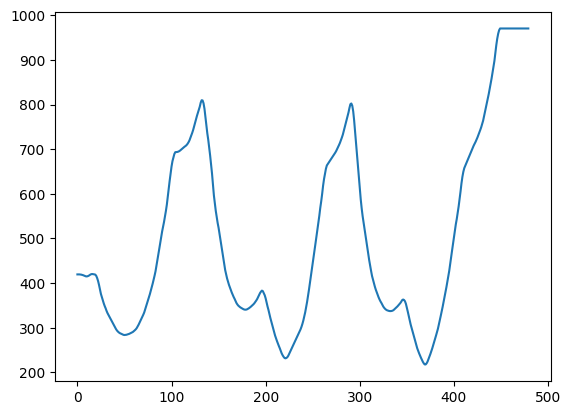

In [7]:
plt.plot(df_ball_positions['mid_y_rolling_mean'])